<a href="https://www.kaggle.com/code/lalit7881/multi-brand-campaign-performance-v1?scriptVersionId=301346327" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/nykaa_campaign_data.csv
/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/purplle_campaign_data.csv
/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/tira_campaign_data.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/nykaa_campaign_data.csv")

In [3]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [4]:
df.tail()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
55550,NY-CMP-56550,SEO,Youth,16,"Instagram, Email",31041,3849,1012,639,162945,374.90,-0.32,Tamil,17.72,Tier 2 City Customers,16-02-2025
55551,NY-CMP-56551,Paid Ads,Tier 2 City Customers,26,Facebook,27335,3715,2184,1006,792728,56.38,12.98,English,25.26,Premium Shoppers,18-11-2024
55552,NY-CMP-56552,Influencer,Tier 2 City Customers,23,"WhatsApp, Facebook, Instagram",43481,6447,3751,1668,383640,56.18,3.09,Bengali,27.29,Working Women,24-10-2024
55553,NY-CMP-56553,Social Media,College Students,16,"Facebook, Email",33530,2518,584,299,194051,227.53,1.85,Bengali,10.14,Working Women,22-05-2025
55554,NY-CMP-56554,Social Media,College Students,25,"YouTube, Instagram, WhatsApp",41096,5254,2570,1894,647748,35.11,8.74,English,23.65,College Students,30-05-2025


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [6]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [7]:
df.isnull().sum()

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Campaign_ID          object
Campaign_Type        object
Target_Audience      object
Duration              int64
Channel_Used         object
Impressions           int64
Clicks                int64
Leads                 int64
Conversions           int64
Revenue               int64
Acquisition_Cost    float64
ROI                 float64
Language             object
Engagement_Score    float64
Customer_Segment     object
Date                 object
dtype: object

In [10]:
df.shape

(55555, 16)

In [11]:
df.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date'],
      dtype='object')

In [12]:
df.nunique()

Campaign_ID         55555
Campaign_Type           5
Target_Audience         5
Duration               26
Channel_Used          156
Impressions         41503
Clicks              12142
Leads                6330
Conversions          4167
Revenue             49394
Acquisition_Cost    37376
ROI                  2483
Language                4
Engagement_Score     2681
Customer_Segment        5
Date                  359
dtype: int64

## EDA

In [13]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

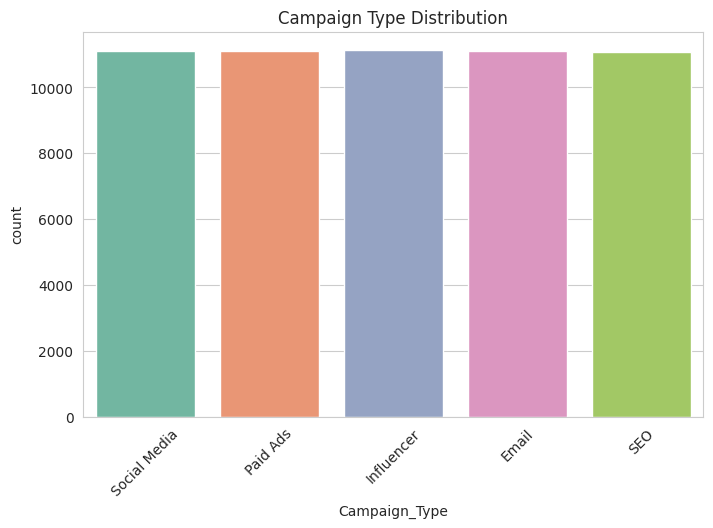

In [14]:
plt.figure()
sns.countplot(x="Campaign_Type", data=df, palette="Set2")
plt.title("Campaign Type Distribution")
plt.xticks(rotation=45)
plt.show()

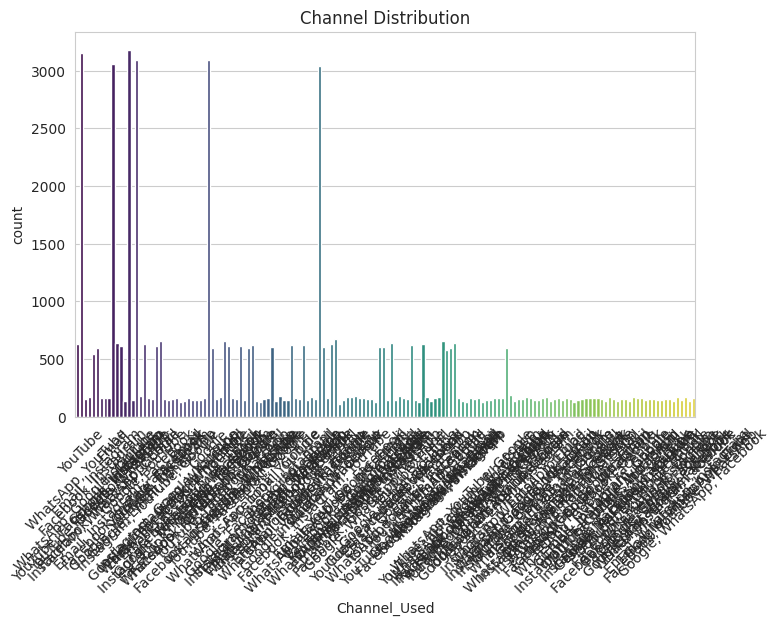

In [15]:
plt.figure()
sns.countplot(x="Channel_Used", data=df, palette="viridis")
plt.title("Channel Distribution")
plt.xticks(rotation=45)
plt.show()

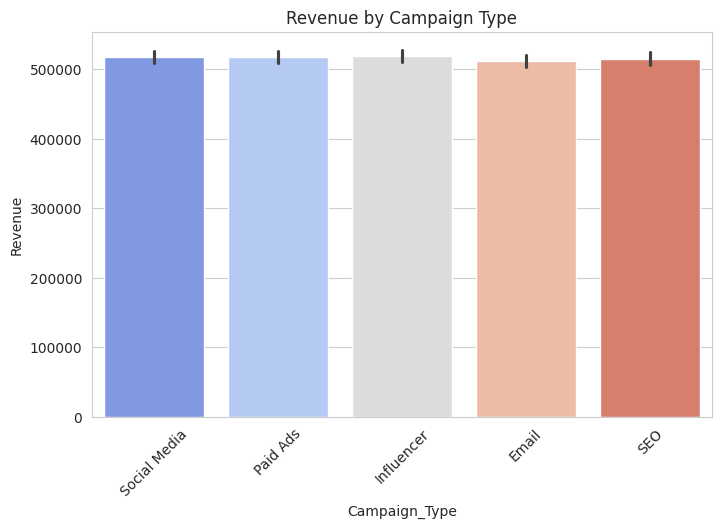

In [16]:
plt.figure()
sns.barplot(x="Campaign_Type", y="Revenue", data=df, palette="coolwarm")
plt.title("Revenue by Campaign Type")
plt.xticks(rotation=45)
plt.show()

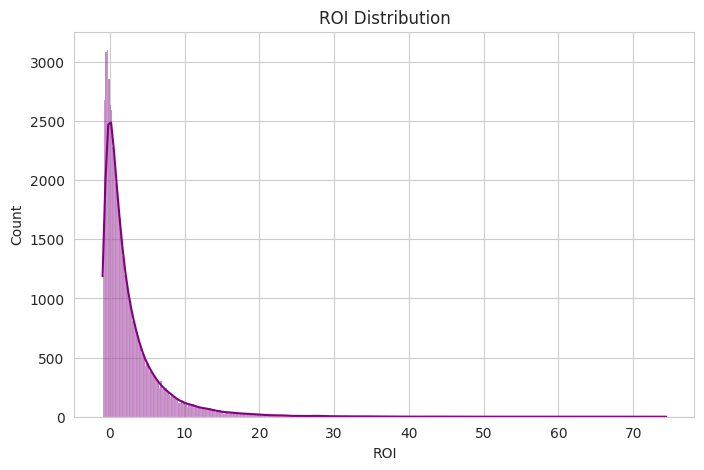

In [17]:
plt.figure()
sns.histplot(df["ROI"], kde=True, color="purple")
plt.title("ROI Distribution")
plt.show()

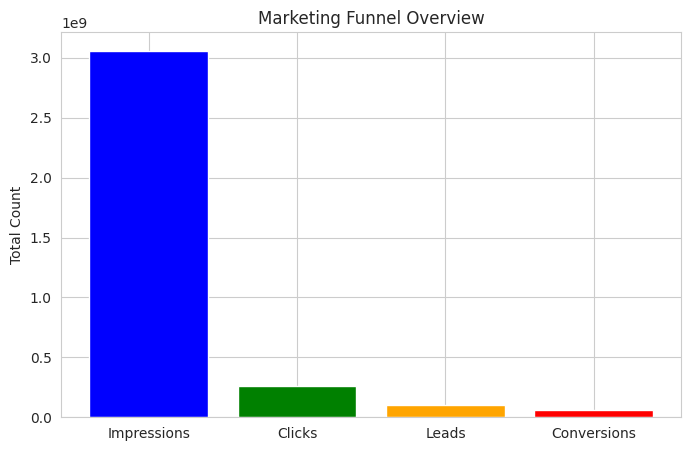

In [18]:
funnel_data = [
    df["Impressions"].sum(),
    df["Clicks"].sum(),
    df["Leads"].sum(),
    df["Conversions"].sum()
]

stages = ["Impressions", "Clicks", "Leads", "Conversions"]

plt.figure()
plt.bar(stages, funnel_data, color=["blue","green","orange","red"])
plt.title("Marketing Funnel Overview")
plt.ylabel("Total Count")
plt.show()

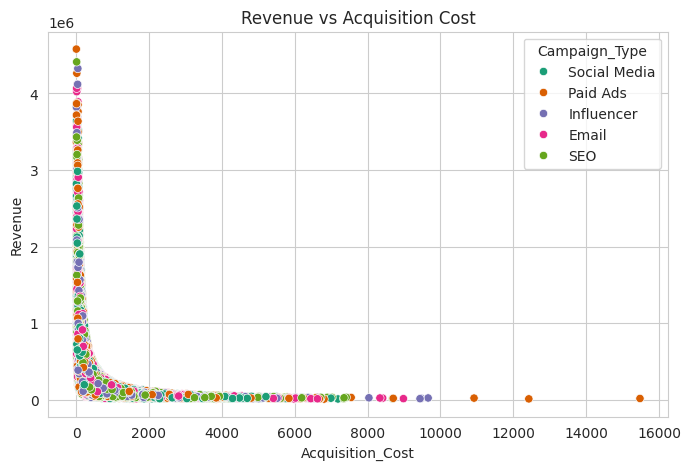

In [19]:
plt.figure()
sns.scatterplot(
    x="Acquisition_Cost",
    y="Revenue",
    hue="Campaign_Type",
    palette="Dark2",
    data=df
)
plt.title("Revenue vs Acquisition Cost")
plt.show()

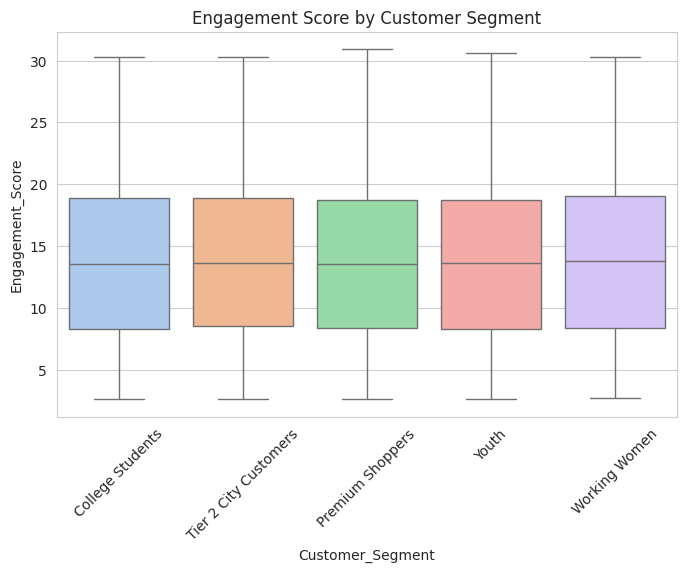

In [20]:
plt.figure()
sns.boxplot(
    x="Customer_Segment",
    y="Engagement_Score",
    data=df,
    palette="pastel"
)
plt.title("Engagement Score by Customer Segment")
plt.xticks(rotation=45)
plt.show()

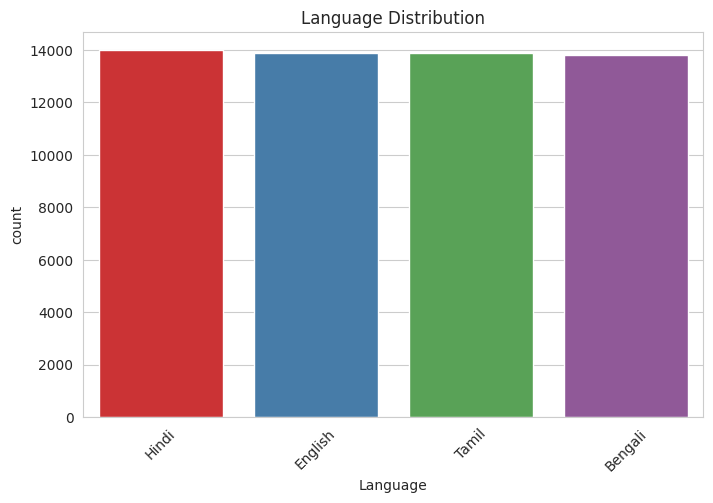

In [21]:
plt.figure()
sns.countplot(x="Language", data=df, palette="Set1")
plt.title("Language Distribution")
plt.xticks(rotation=45)
plt.show()

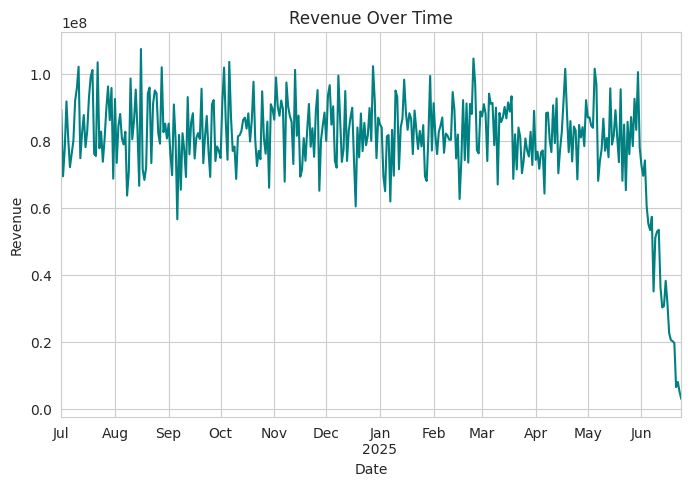

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

revenue_trend = df.groupby("Date")["Revenue"].sum()

plt.figure()
revenue_trend.plot(color="teal")
plt.title("Revenue Over Time")
plt.ylabel("Revenue")
plt.show()

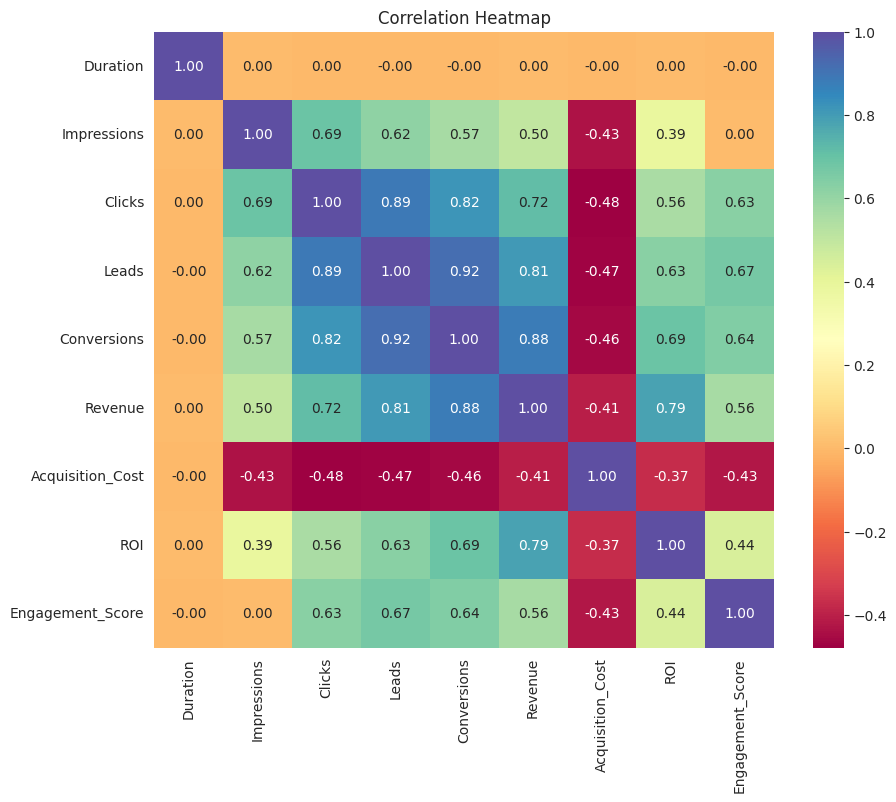

In [23]:
numeric_cols = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="Spectral", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [25]:
df = df.drop(columns=["Campaign_ID"], errors="ignore")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Extract useful date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df = df.drop(columns=["Date"])

# Fill numeric missing values
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [26]:
roi_median = df["ROI"].median()
df["High_ROI"] = np.where(df["ROI"] > roi_median, 1, 0)

# ⚠️ Remove leakage columns
df = df.drop(columns=["ROI", "Revenue", "Conversions"], errors="ignore")

X = df.drop("High_ROI", axis=1)
y = df["High_ROI"]

# Check class balance
print("Class Distribution:\n", y.value_counts())

Class Distribution:
 High_ROI
0    27822
1    27733
Name: count, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

In [30]:
results = {}

for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    
    print("\n==============================")
    print(name)
    print("Accuracy: {:.2f}%".format(acc))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 87.71%

Confusion Matrix:
[[4734  830]
 [ 536 5011]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      5564
           1       0.86      0.90      0.88      5547

    accuracy                           0.88     11111
   macro avg       0.88      0.88      0.88     11111
weighted avg       0.88      0.88      0.88     11111


Random Forest
Accuracy: 87.62%

Confusion Matrix:
[[4732  832]
 [ 543 5004]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      5564
           1       0.86      0.90      0.88      5547

    accuracy                           0.88     11111
   macro avg       0.88      0.88      0.88     11111
weighted avg       0.88      0.88      0.88     11111


SVM
Accuracy: 87.36%

Confusion Matrix:
[[4650  914]
 [ 490 5057]]

Classification Report:
              precision    recall  f1-score 

In [31]:
trained_pipes = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe

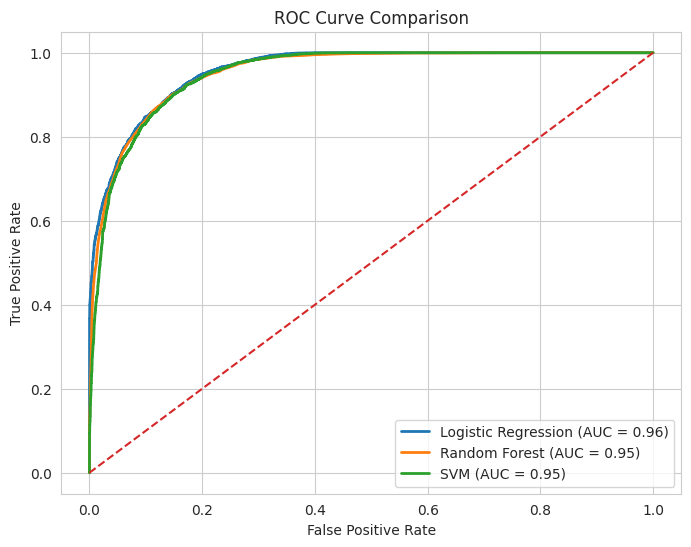

In [32]:
plt.figure(figsize=(8,6))

for name, pipe in trained_pipes.items():
    
    model = pipe.named_steps["model"]
    
    # Use probability if available
    if hasattr(model, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Thank you..pls upvote!!!!!